#### Business understanding and problem framing
**Businees Problem** : A retail company has a diverse customer base but currently uses the same marketing strategy for all customers. As a result, marketing campaigns are less effective, customer engagement is low, and marketing resources are not used efficiently. The company needs to segment its customers based on their purchasing behavior to deliver personalized marketing campaigns and improve customer retention and sales.
- **Hypothesis** :Customers have distinct purchasing behaviors that can be grouped into meaningful segments
- **Test_of_hypothesis** : Test the hypothesis that customers can be segmented 

#### Data Description
- **Response** Indicates whether the customer accepted the most recent marketing campaign (1 = Yes, 0 = No)
- **Education** Customer's highest level of education (e.g., Basic, Graduation, Master's, PhD).
- **Income** Customer's annual household income
- **KidHome** Number of young children living in the customer's household.
- **TeenHome** Number of teenagers living in the customer's household.
- **Recency** Number of days since the customer's last purchase. Lower values indicate more recent purchases.
- **MntWines**	Total amount spent on wine products over the analysis period.
- **MntFruits**	Total amount spent on fruit products over the analysis period.
- **MntMeatProducts** Total amount spent on meat products over the analysis period.
- **MntFishProducts** Total amount spent on fish products over the analysis period.
- **MntSweetProducts** Total amount spent on sweet products over the analysis period
- **NumDealsPurchases**	Number of purchases made using promotional deals or discounts.
- **NumWebPurchases** Number of purchases made through the company's website.
- **NumCatalogPurchases** Number of purchases made through the company's catalog.
- **NumStorePurchases** Number of purchases made in physical stores.
- **NumWebVisitsMonth**	Number of visits to the company's website in the last month.
- **AcceptedCmp3** Indicates whether the customer accepted the third marketing campaign (1 = Yes, 0 = No).
- **AcceptedCmp4** Indicates whether the customer accepted the fourth marketing campaign (1 = Yes, 0 = No).
- **AcceptedCmp5** Indicates whether the customer accepted the fifth marketing campaign (1 = Yes, 0 = No).
- **AcceptedCmp1** Indicates whether the customer accepted the first marketing campaign (1 = Yes, 0 = No).
- **AcceptedCmp2** Indicates whether the customer accepted the second marketing campaign (1 = Yes, 0 = No).

#### Import Packages

In [226]:
import pandas as pd
import numpy
import matplotlib

#### Data Collection & Data Understanding

In [227]:
df = pd.read_csv("customer_segmentation_ML_Project.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [228]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [229]:
df.shape

(2240, 29)

We have 2240 instances and 29 attributes

In [230]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

#### Variable summary
- We have 26 numerical columns and 3 objects in the dataset

#### Data cleaning & Preprocessing

In [231]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

  We have 24 missing values in "income" columns, we can drop it since that dataset have 2240 rows

In [232]:
df.dropna(inplace=True)

In [233]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

**Check for Text Inconsistencies**

In [234]:
df.Marital_Status.unique()

<ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str

In [235]:
df.Education.unique()

<ArrowStringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

#### Statistical summary

In [236]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


#### Feature Engineering

In [237]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [238]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [239]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

In [240]:
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

In [241]:
df['Age'] = 2026 - df['Year_Birth']

In [242]:
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,72


In [243]:
df['Total_children'] = df['Kidhome'] + df['Teenhome']

In [244]:
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,3,11,1,69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,3,11,0,72,2


In [245]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children'],
      dtype='str')

In [246]:
consumption= ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

In [247]:
df['Total_spending'] = df[consumption].sum(axis =True)

In [248]:
df['Total_spending']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_spending, Length: 2216, dtype: int64

In [249]:
df.head(1)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,69,0,1617


In [250]:
print(df['Dt_Customer'].min())
print(df['Dt_Customer'].max())


2012-07-30 00:00:00
2014-06-29 00:00:00


In [251]:
df['Customer_Tenure'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days//365

In [252]:
df['Customer_Tenure'].head(8)

0    13
1    12
2    12
3    12
4    12
5    12
6    13
7    13
Name: Customer_Tenure, dtype: int64

In [253]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spending,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,69,0,1617,13
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,72,2,27,12
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,61,0,776,12
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,42,1,53,12
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,45,1,422,12


### EDA
**Distribution of numerical columns**

In [254]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_Tenure'],
      dtype='str')

In [255]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

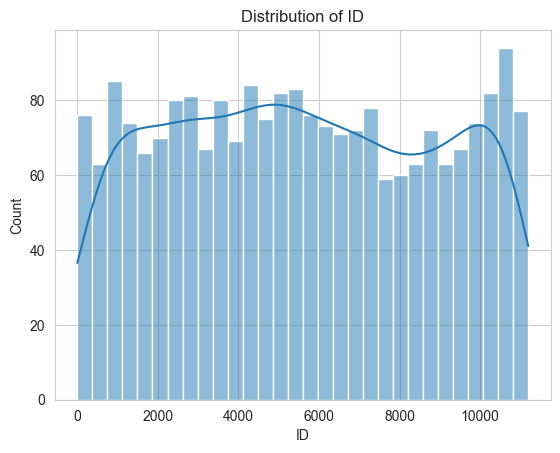

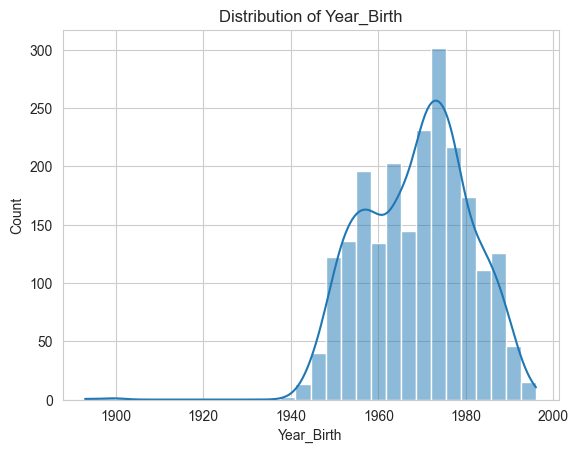

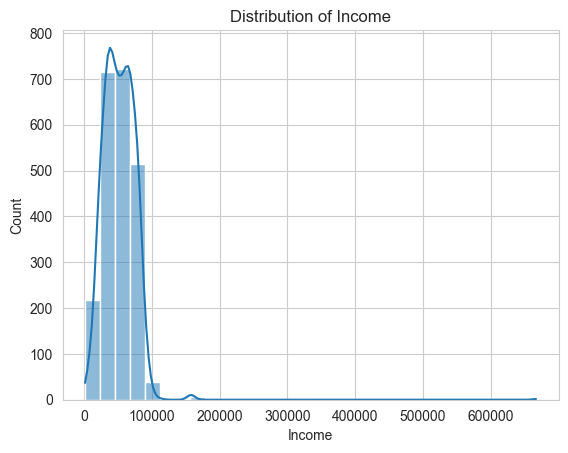

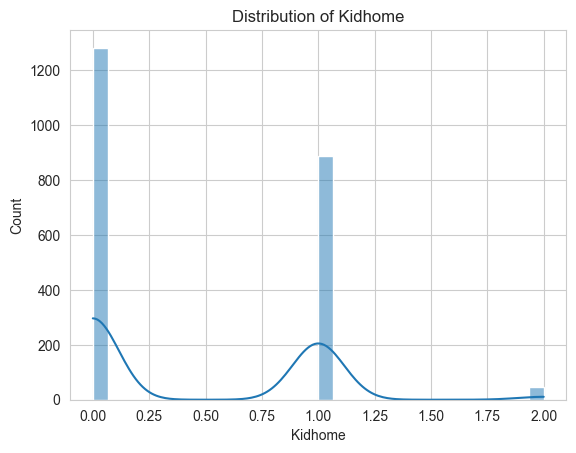

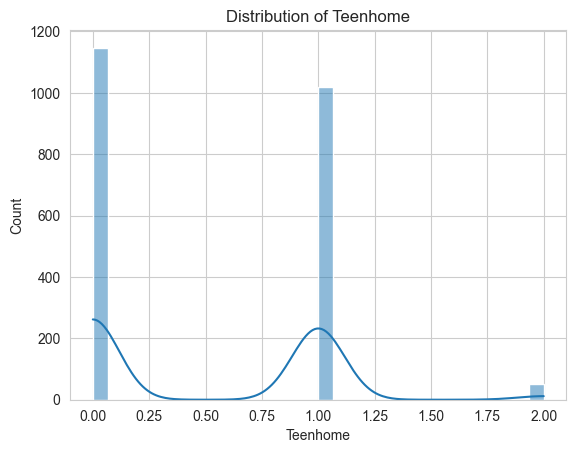

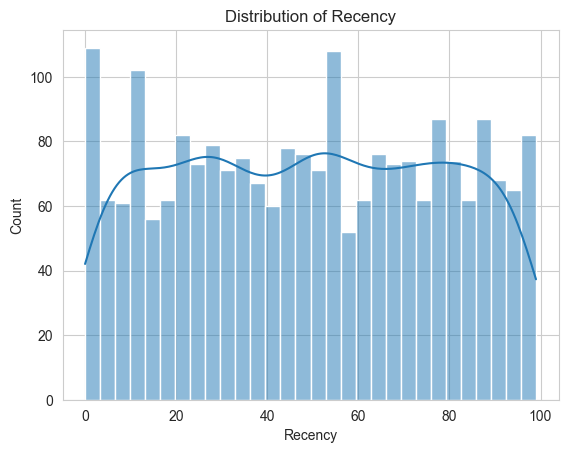

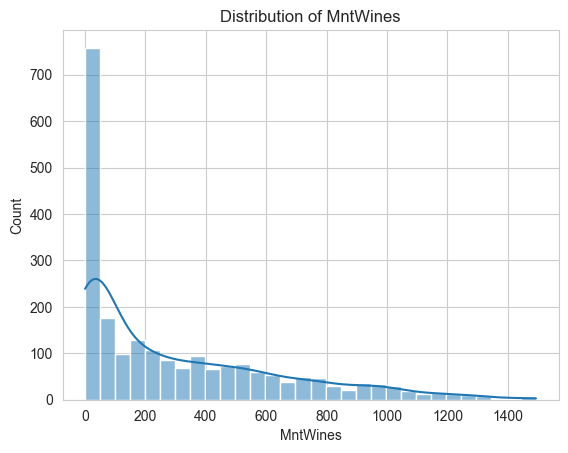

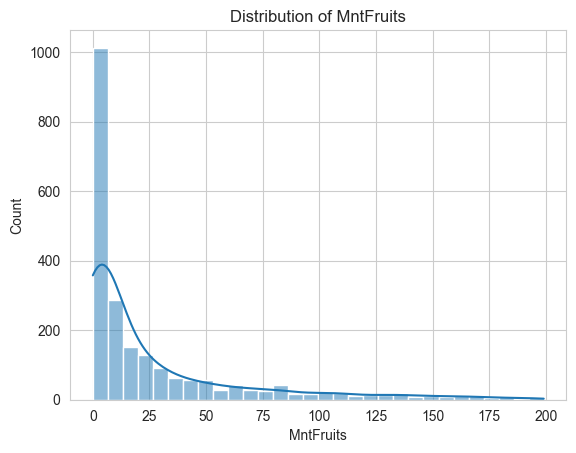

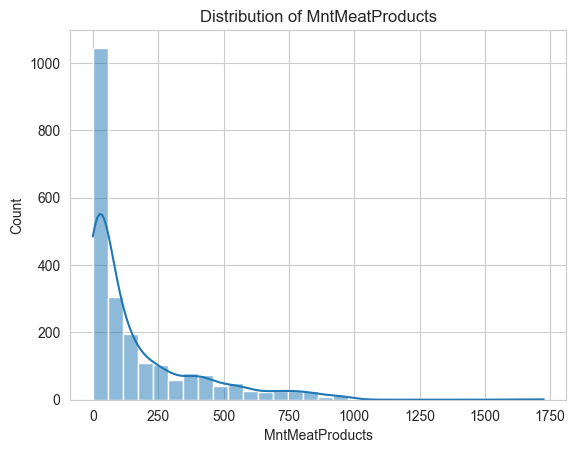

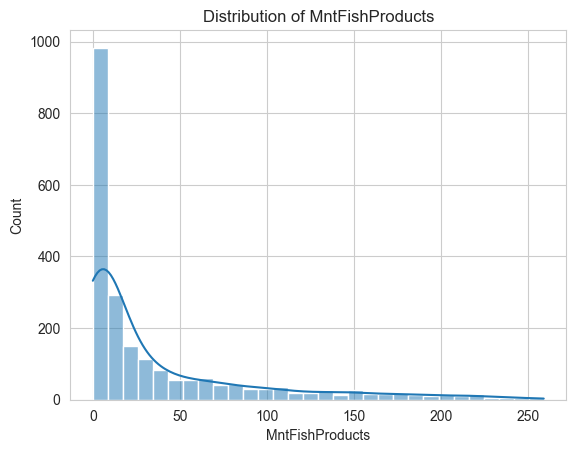

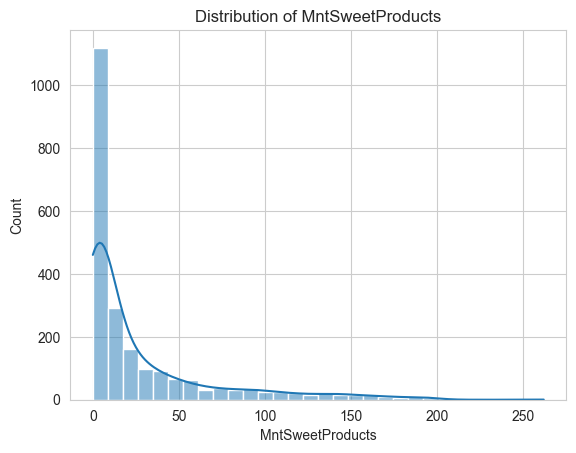

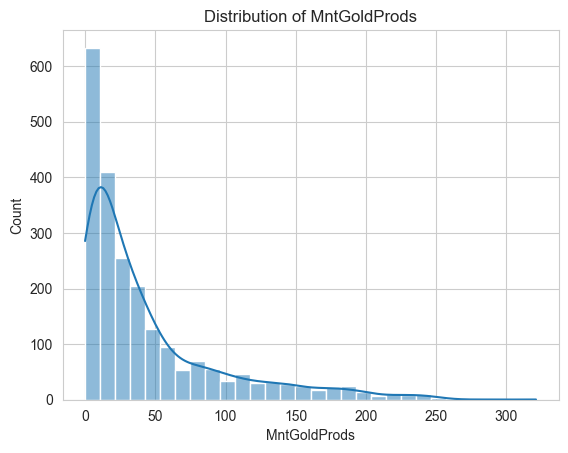

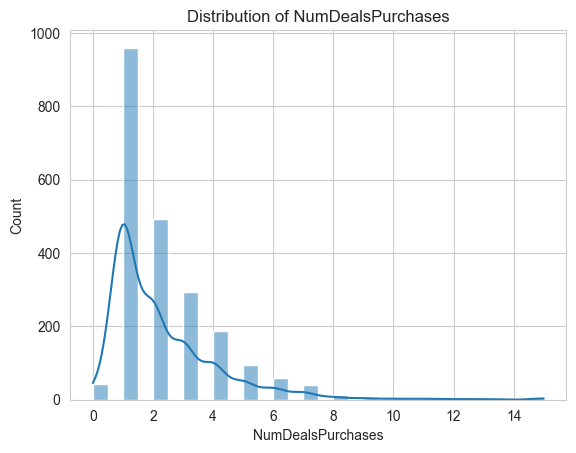

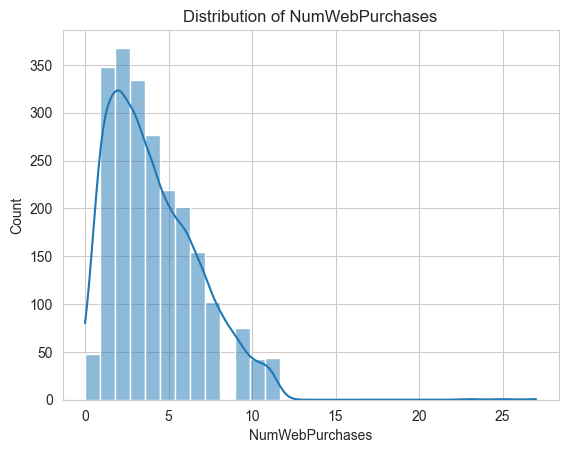

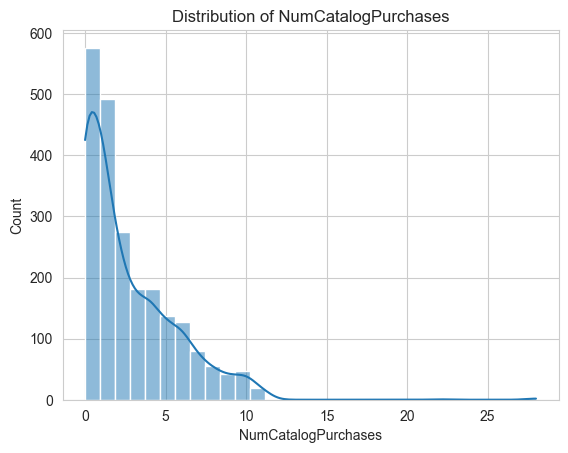

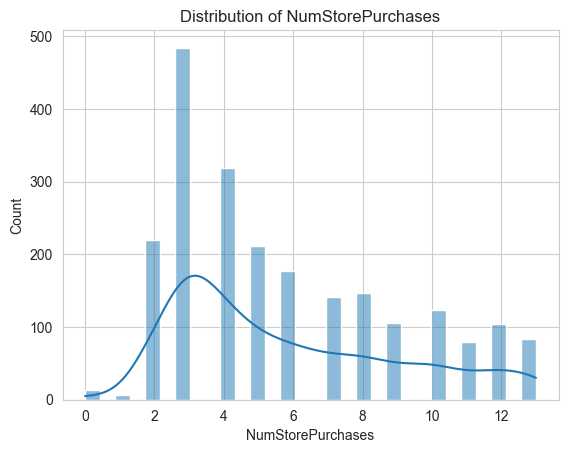

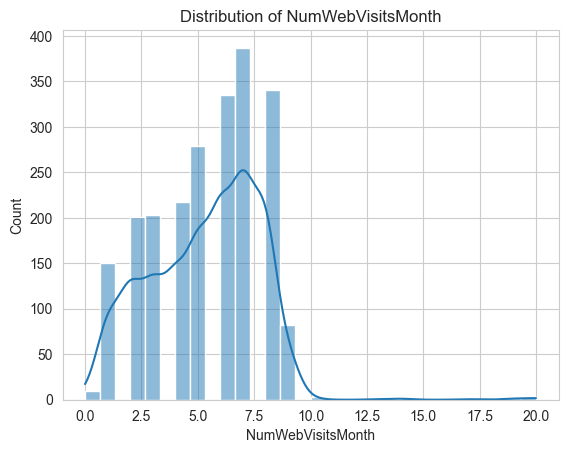

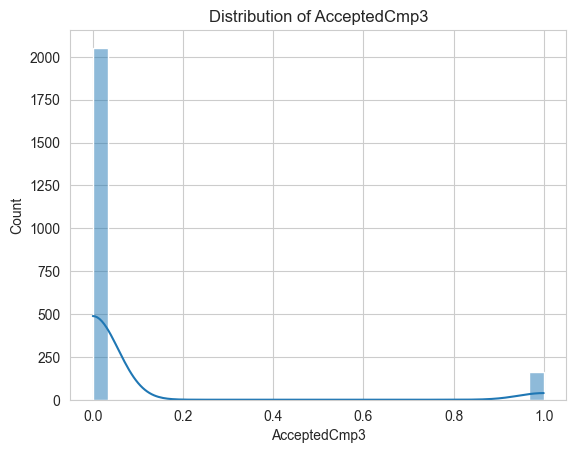

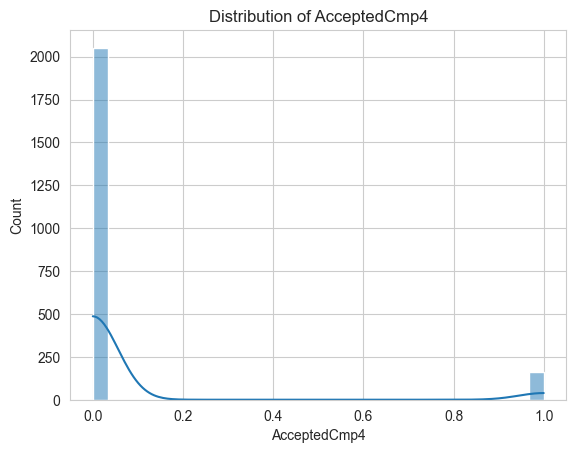

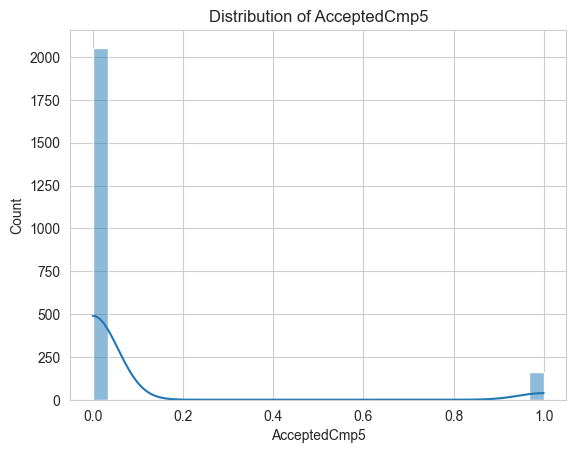

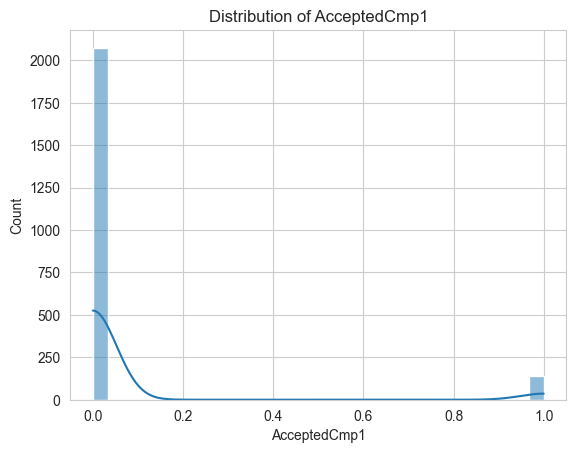

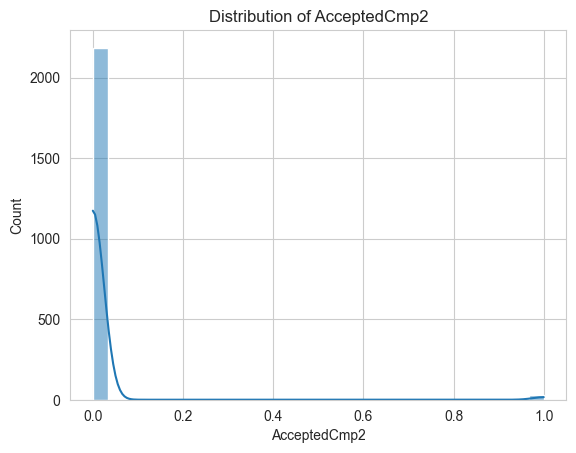

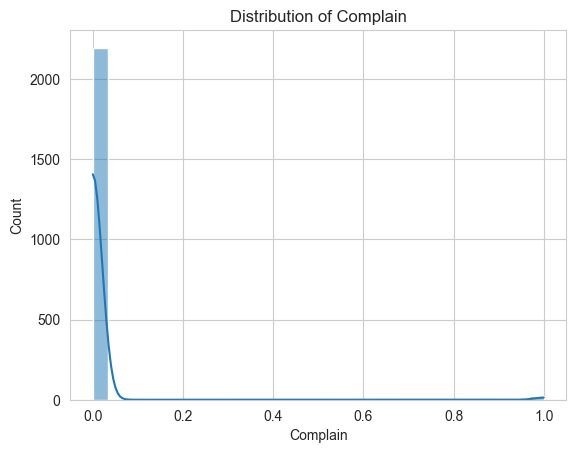

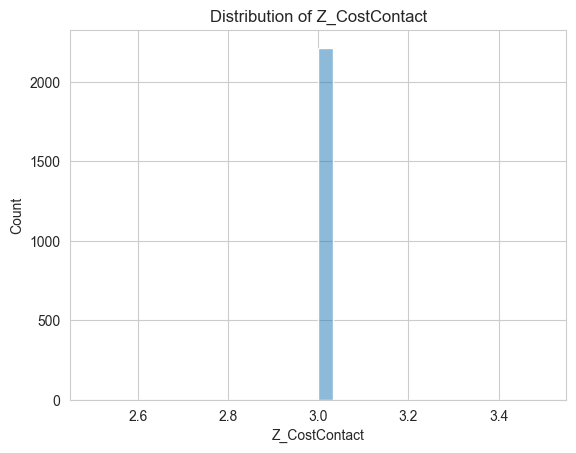

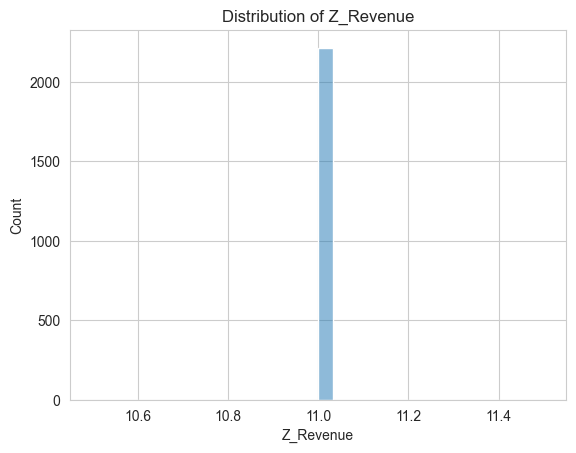

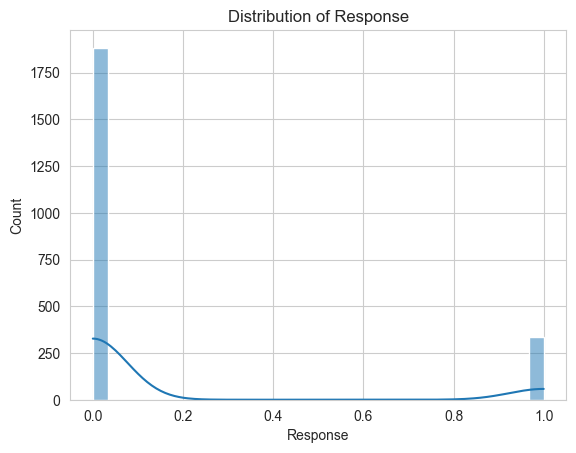

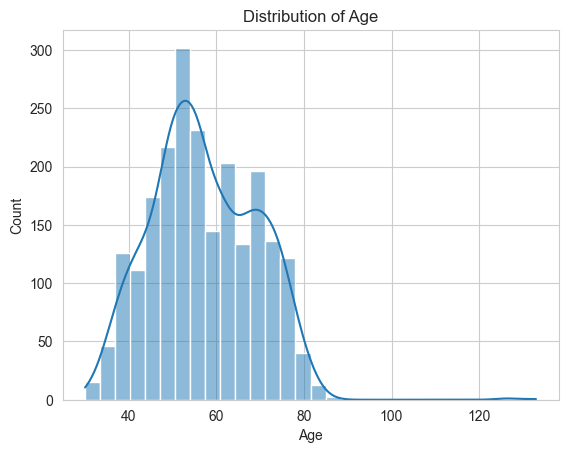

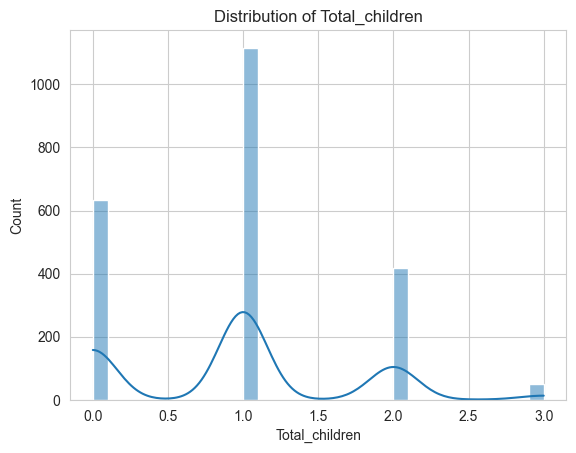

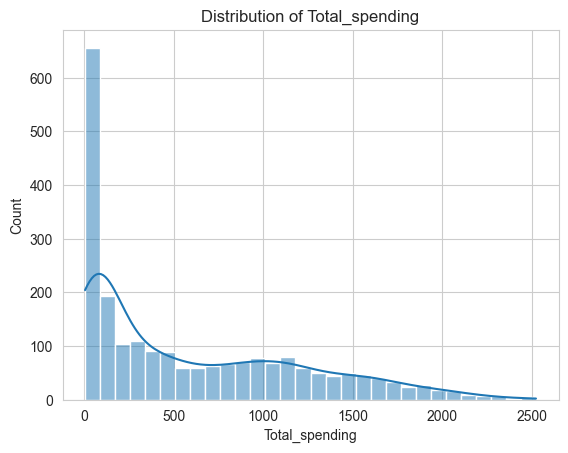

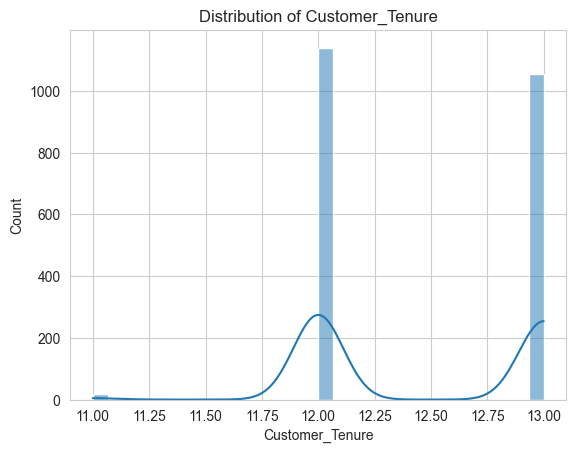

In [256]:

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:

    sns.histplot(df[col],bins=30,kde=True)

    plt.title(f"Distribution of {col}")
    plt.show()

#### Observation
- Clearly, the **Total_spending** ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'] is highly positively skewed, presenting a very long right-tail towards the higher values of the distribution. The values on the higher and lower end of the distribution are likely to be outliers.
- Similarly to the **Total_spending plots**, we can observe that a lot of the variables are highly positively skewed, creating a very long tail for the higher values. We will make use of "Transformation Technique" to correct this skewness.
-  The **Purchases** [NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases] is highly positively skewed, presenting a very long right-tail towards the higher values of the distribution.

#### Correlation

In [257]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_Tenure'],
      dtype='str')

In [258]:
corr = df[['Income','Recency','NumDealsPurchases','NumWebPurchases', 'NumCatalogPurchases','NumStorePurchases']].corr()             

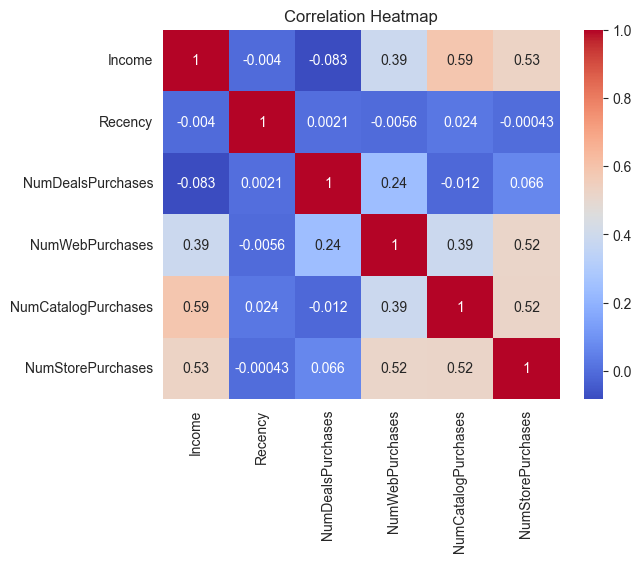

In [259]:
sns.heatmap(corr, annot =True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Average Spending by Education**

In [260]:
group1 = df.groupby('Education')['Total_spending'].mean().sort_values(ascending=False)
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_spending, dtype: float64

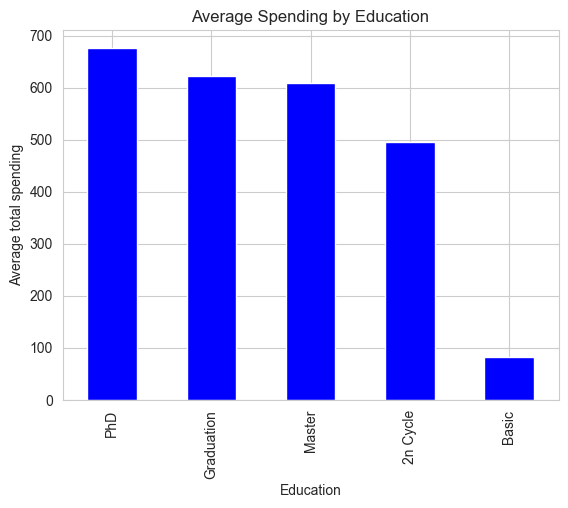

In [261]:
group1.plot(kind='bar',color ='blue')
plt.title('Average Spending by Education')
plt.ylabel("Average total spending")
plt.show()


**Average spending by marital status**

In [262]:
group = df.groupby('Marital_Status')['Total_spending'].mean().sort_values(ascending=False)
group

Marital_Status
Absurd      1192.500000
Widow        727.960526
Single       612.592357
Divorced     610.629310
Together     608.846422
Married      591.464411
YOLO         424.000000
Alone        256.666667
Name: Total_spending, dtype: float64

Text(0, 0.5, 'Average Total_spending')

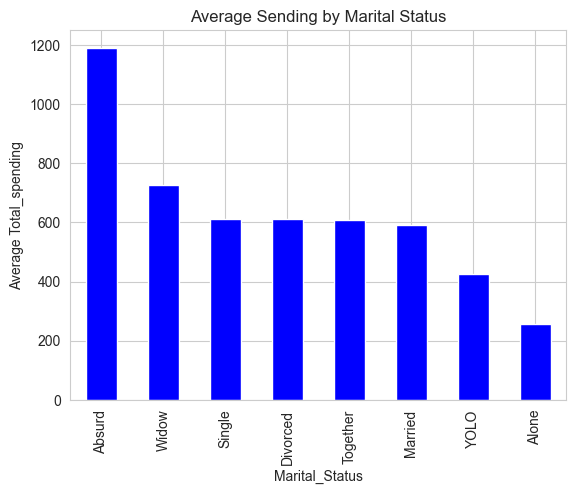

In [263]:
import seaborn as sns
sns.set_style("whitegrid")
group.plot(kind='bar', color='blue')
plt.title('Average Sending by Marital Status')
plt.ylabel('Average Total_spending')

**Average Accepted Campagn Rate by Marital Status**

In [264]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_Tenure'],
      dtype='str')

**The total number of acceptances for each campaign across all customers**

In [265]:
df['Accepted_Campaign'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

In [266]:
df['Accepted_Campaign']

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: Accepted_Campaign, Length: 2216, dtype: int64

In [267]:
df['Accepted_Campaign'].unique()

array([1, 0, 3, 2, 4, 5])

The acceptance campaign rate for each customers is either 1,0,3,2,4 o9r 5

In [268]:
df['Accepted_Campaign'] = df['Accepted_Campaign'].apply(lambda x:1 if x > 0 else 0)

In [269]:
df['Accepted_Campaign'].unique()

array([1, 0])

For the Campaign Rate, 1 is accepted while 0 is unaccepted

**Average Accepted Campagn Rate by Marital Status**

In [270]:
group2 = df.groupby('Marital_Status')['Accepted_Campaign'].mean().sort_values(ascending = False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: Accepted_Campaign, dtype: float64

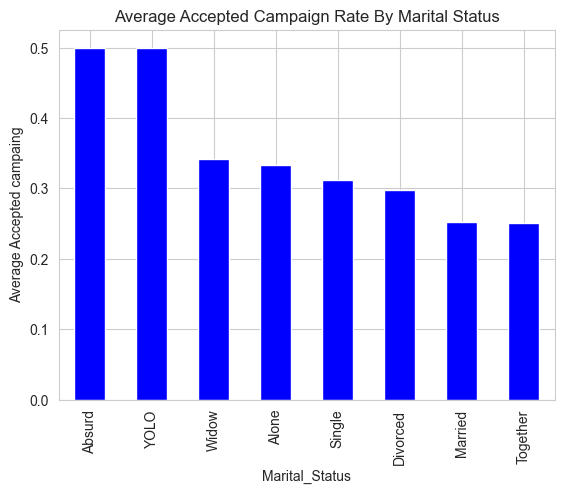

In [271]:
group2.plot(kind='bar',color= 'Blue')
plt.title('Average Accepted Campaign Rate By Marital Status')
plt.ylabel('Average Accepted campaing')
plt.show()

**Average Income by Age group**

In [272]:
# Bins defines where each age group starts and ends.
bins = [18,30,40,50,60,70,90]

In [273]:

labels = ['18-29','30-39','40-49','50-59','60-69', '70+' ]

In [274]:
# Categorize each customers Age 
df['Age_group'] = pd.cut(df['Age'],bins=bins, labels = labels)
# pd.cut() checks each customer's age and places it into the correct group.
df['Age_group'] 

0       60-69
1         70+
2       60-69
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: Age_group, Length: 2216, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [275]:
group3 = df.groupby('Age_group')['Income'].mean().sort_values(ascending = False)
group3

Age_group
70+      58767.083102
60-69    55980.030928
50-59    50479.321534
40-49    48057.587649
30-39    47905.475676
18-29    10960.500000
Name: Income, dtype: float64

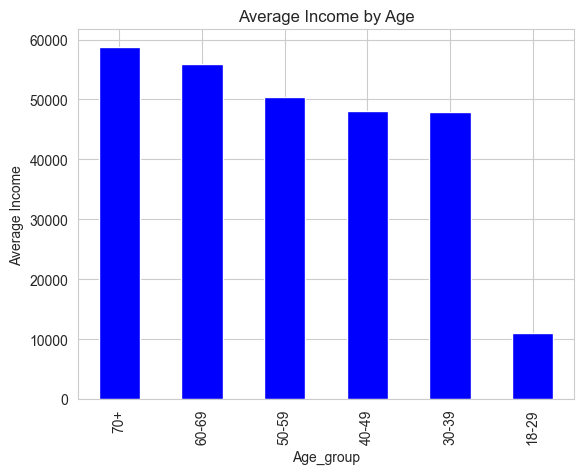

In [276]:
group3.plot(kind='bar',color='blue')
plt.title('Average Income by Age')
plt.ylabel('Average Income')
plt.show()

## Transforming numerical data
The reason why we need to treat skewness is because some predictive models have inherent assumptions about the distribution of the features. Such models are called `parametric` models, and they typically assume that all variables are both independent and normally distributed.

Skewness isn't always a bad thing, but as a rule of thumb it is good practice to treat highly skewed variables to make them more normally distributed. This can also increase the speed at which predictive models are able to converge to the best solution.

There are many ways that you can treat skewed variables. You can apply transformations such as:
- Square root
- Cubic root
- Logarithm
- Box-cox

In [277]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_Tenure',
       'Accepted_Campaign', 'Age_group'],
      dtype='str')

In [278]:
skewed_columns = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'Total_spending', 
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

In [279]:
print("\nBefore log transform:")
print(df[skewed_columns].describe())


Before log transform:
              Income     MntWines    MntFruits  MntMeatProducts  \
count    2216.000000  2216.000000  2216.000000      2216.000000   
mean    52247.251354   305.091606    26.356047       166.995939   
std     25173.076661   337.327920    39.793917       224.283273   
min      1730.000000     0.000000     0.000000         0.000000   
25%     35303.000000    24.000000     2.000000        16.000000   
50%     51381.500000   174.500000     8.000000        68.000000   
75%     68522.000000   505.000000    33.000000       232.250000   
max    666666.000000  1493.000000   199.000000      1725.000000   

       MntFishProducts  MntSweetProducts  MntGoldProds  Total_spending  \
count      2216.000000       2216.000000   2216.000000     2216.000000   
mean         37.637635         27.028881     43.965253      607.075361   
std          54.752082         41.072046     51.815414      602.900476   
min           0.000000          0.000000      0.000000        5.000000   
25%

In [280]:

df[skewed_columns] = np.log10(df[skewed_columns] + 1)
print("After log transform:")
print(df[skewed_columns].describe())

After log transform:
            Income     MntWines    MntFruits  MntMeatProducts  \
count  2216.000000  2216.000000  2216.000000      2216.000000   
mean      4.670327     2.031439     0.974222         1.793528   
std       0.219685     0.784187     0.681756         0.678093   
min       3.238297     0.000000     0.000000         0.000000   
25%       4.547824     1.397940     0.477121         1.230449   
50%       4.710815     2.244275     0.954243         1.838849   
75%       4.835836     2.704151     1.531479         2.367821   
max       5.823909     3.174351     2.301030         3.237041   

       MntFishProducts  MntSweetProducts  MntGoldProds  Total_spending  \
count      2216.000000       2216.000000   2216.000000     2216.000000   
mean          1.102445          0.973523      1.355985        2.442093   
std           0.719717          0.691683      0.559121        0.638596   
min           0.000000          0.000000      0.000000        0.778151   
25%           0.602060 

We can see that the standard deviation reduced after the transformation

### Declare Feature Vector and Target Variable

In [281]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_children', 'Total_spending', 'Customer_Tenure',
       'Accepted_Campaign', 'Age_group'],
      dtype='str')

In [282]:
Feature = ['Age','Recency','Income','NumStorePurchases','NumWebPurchases','NumWebVisitsMonth','Total_spending','Customer_Tenure']

#### Check for multicollinearity

In [283]:
df[Feature].corr()

,Age,Recency,Income,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Total_spending,Customer_Tenure
Age,1.000000,0.016295,0.227485,0.140661,0.153119,-0.123904,0.165939,-0.006515
Recency,0.016295,1.000000,0.005916,0.005040,0.003816,-0.018564,0.016887,0.025174
Income,0.227485,0.005916,1.000000,0.666208,0.526518,-0.602325,0.750634,-0.009102
NumStorePurchases,0.140661,0.005040,0.666208,1.000000,0.644467,-0.456459,0.797872,0.090278
NumWebPurchases,0.153119,0.003816,0.526518,0.644467,1.000000,-0.109717,0.777315,0.161044
NumWebVisitsMonth,-0.123904,-0.018564,-0.602325,-0.456459,-0.109717,1.000000,-0.461087,0.230938
Total_spending,0.165939,0.016887,0.750634,0.797872,0.777315,-0.461087,1.000000,0.164210
Customer_Tenure,-0.006515,0.025174,-0.009102,0.090278,0.161044,0.230938,0.164210,1.000000


There is no multicollinearity because the predictors are not highly correlated

In [284]:
X = df[Feature].copy()

#### Feature Scaling

In [285]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [286]:
X_scaled = scaler.fit_transform(X)

In [287]:
X_scaled

array([[ 0.98644293,  0.31053212,  0.42862317, ...,  0.69323197,
         1.20116378,  1.03134529],
       [ 1.23680074, -0.38050944, -0.01968606, ..., -0.1315745 ,
        -1.55835429, -0.90712898],
       [ 0.31882209, -0.79513438,  0.84080758, ..., -0.54397773,
         0.70221103, -0.90712898],
       ...,
       [-1.01641959,  1.4507507 ,  0.38887611, ...,  0.28082874,
         1.02126477, -0.90712898],
       [ 1.06989553, -1.41707178,  0.77431909, ..., -0.95638097,
         0.75847433, -0.90712898],
       [ 1.23680074, -0.31140528,  0.24077454, ...,  0.69323197,
        -0.31959589,  1.03134529]], shape=(2216, 8))

### K-Means clustering 
is an unsupervised learning method for clustering data points.
In unsupervised Learning, all you have are set of features, you don't know about your class variable , label or target variable.
K means tries to underline the structure in that data or sometimes find the cluster in the data and make useful information out of it.
* K is a paramter , which helps to identify the random points ,which is the centroid of the clusters.
- SSE is sum of squared Error

In [288]:
from sklearn.cluster import KMeans

**Elbow Method**

In [289]:
KMeans_range = range(1, 10)
SSE = []

for k in KMeans_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    SSE.append(km.inertia_)

In [290]:
SSE

[17728.0,
 11701.569424014171,
 10277.604146674868,
 9335.738643345529,
 8728.114171737972,
 8249.93404167814,
 7875.561274689692,
 7485.119983307917,
 7170.769578249262]

Text(0, 0.5, 'SSE')

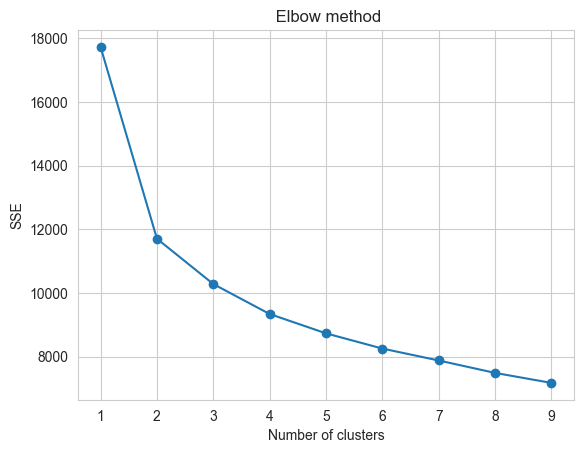

In [291]:
plt.plot(KMeans_range,SSE, marker ='o')
plt.title(' Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')

In [292]:
Kmeans =  KMeans( n_clusters=4,random_state=42, n_init=10)
df['clusters'] = Kmeans.fit_predict(X_scaled)

In [293]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_children,Total_spending,Customer_Tenure,Accepted_Campaign,Age_group,clusters
0,5524,1957,Graduation,Single,4.764468,0,0,2012-09-04,58,2.803457,...,3,11,1,69,0,3.208979,13,1,60-69,0
1,2174,1954,Graduation,Single,4.666003,1,1,2014-03-08,38,1.079181,...,3,11,0,72,2,1.447158,12,0,70+,2
2,4141,1965,Graduation,Together,4.854998,0,0,2013-08-21,26,2.630428,...,3,11,0,61,0,2.890421,12,0,60-69,3
3,6182,1984,Graduation,Together,4.425648,1,0,2014-02-10,26,1.079181,...,3,11,0,42,1,1.732394,12,0,40-49,2
4,5324,1981,PhD,Married,4.765624,1,0,2014-01-19,94,2.240549,...,3,11,0,45,1,2.626340,12,0,40-49,3


In [294]:
cluster_summary = df.groupby('clusters')[Feature].mean().sort_values(by = ['Income'],ascending = False)
cluster_summary

,Age,Recency,Income,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Total_spending,Customer_Tenure
clusters,,,,,,,,
3,59.655000,47.941667,4.824227,0.925438,0.769523,3.603333,2.899141,11.981667
0,59.456808,49.995608,4.790100,0.924397,0.817321,5.169839,2.941229,13.000000
2,54.492832,48.589606,4.521405,0.593747,0.427996,5.921147,1.747885,11.992832
1,53.069333,49.565333,4.427534,0.578752,0.438589,7.440000,1.834704,12.984000


In [295]:
df.clusters.value_counts()

clusters
0    683
3    600
2    558
1    375
Name: count, dtype: int64

In [296]:
from sklearn.decomposition import PCA
# Initialize
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:,0] , pca_data[:,1] 

In [297]:
pca_data

array([[ 1.12525838,  1.54015277],
       [-1.88846518, -1.61714021],
       [ 2.03480623, -0.56454779],
       ...,
       [ 0.9664252 , -0.42467589],
       [ 2.08363088, -1.0147811 ],
       [-0.30201475,  0.8438813 ]], shape=(2216, 2))

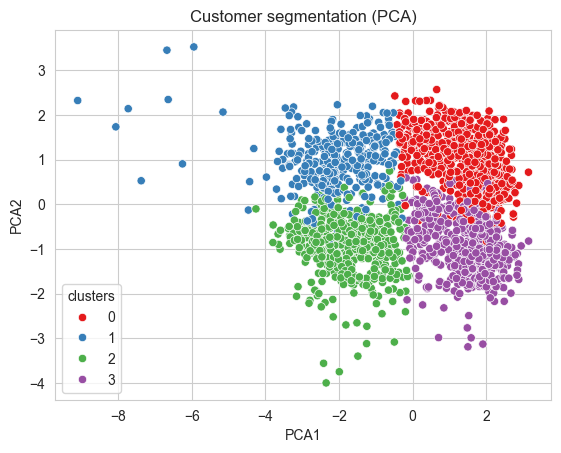

In [298]:
sns.scatterplot(x='PCA1', y = 'PCA2' , hue = 'clusters' , data = df, palette = 'Set1')
plt.title('Customer segmentation (PCA)')
plt.show()

In [299]:
cluster_summary

,Age,Recency,Income,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Total_spending,Customer_Tenure
clusters,,,,,,,,
3,59.655000,47.941667,4.824227,0.925438,0.769523,3.603333,2.899141,11.981667
0,59.456808,49.995608,4.790100,0.924397,0.817321,5.169839,2.941229,13.000000
2,54.492832,48.589606,4.521405,0.593747,0.427996,5.921147,1.747885,11.992832
1,53.069333,49.565333,4.427534,0.578752,0.438589,7.440000,1.834704,12.984000


| clusters| characteristics | segment |
|----------|---------|----------------|
| **3** | Highest income, highest spending customers | **Loyal customers** |
| **0** | High income and  moderate spending customers | **High-Potential Customers**|
| **2** |Medium income and low spending customers |**Average customers**|
| **1** |Lowest income and low spending customers |**Price-conscious customers**|

In [300]:
import joblib
joblib.dump(Kmeans ,'Kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']